In [1]:
import pandas as pd
import numpy as np

pd.set_option("display.max_columns", None)

In [2]:
df = pd.read_csv("../data/processed/cleaned_data.csv")

df["Date"] = pd.to_datetime(df["Date"])

print("Dataset loaded successfully!")
print("Rows:", len(df))

Dataset loaded successfully!
Rows: 1170


In [3]:
numeric_columns = [
    "Children apprehended and placed in CBP custody",
    "Children in CBP custody",
    "Children transferred out of CBP custody",
    "Children in HHS Care",
    "Children discharged from HHS Care"
]

for col in numeric_columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

KeyError: 'Children apprehended and placed in CBP custody'

In [4]:
print("Columns in dataset:")
for i, col in enumerate(df.columns):
    print(i, repr(col))

Columns in dataset:
0 'Date'
1 'Children apprehended and placed in CBP custody*'
2 'Children in CBP custody'
3 'Children transferred out of CBP custody'
4 'Children in HHS Care'
5 'Children discharged from HHS Care'


In [5]:
cols = [
    "Children in CBP custody",
    "Children transferred out of CBP custody",
    "Children in HHS Care",
    "Children discharged from HHS Care"
]

for col in cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

print("Numeric conversion completed!")

Numeric conversion completed!


In [6]:
print(df[cols].dtypes)

Children in CBP custody                    float64
Children transferred out of CBP custody    float64
Children in HHS Care                       float64
Children discharged from HHS Care          float64
dtype: object


In [7]:
df["Total System Load"] = (
    df["Children in CBP custody"] +
    df["Children in HHS Care"]
)

df["Net Daily Intake"] = (
    df["Children transferred out of CBP custody"] -
    df["Children discharged from HHS Care"]
)

print("KPI metrics created successfully!")

KPI metrics created successfully!


In [8]:
df[[
    "Date",
    "Total System Load",
    "Net Daily Intake"
]].head()

,Date,Total System Load,Net Daily Intake
0,2023-01-12,NaN,-402.0
1,2023-01-22,NaN,-188.0
2,2023-01-23,NaN,-142.0
3,2023-01-24,NaN,-128.0
4,2023-01-25,NaN,-139.0


In [9]:
average_system_load = df["Total System Load"].mean()
maximum_system_load = df["Total System Load"].max()
minimum_system_load = df["Total System Load"].min()

print("Average Total Children Under Care:", round(average_system_load, 2))
print("Maximum System Load:", maximum_system_load)
print("Minimum System Load:", minimum_system_load)

Average Total Children Under Care: nan
Maximum System Load: nan
Minimum System Load: nan


In [10]:
net_intake_pressure = df["Net Daily Intake"].mean()

print(
    "Average Net Intake Pressure:",
    round(net_intake_pressure, 2)
)

Average Net Intake Pressure: -44.74


In [11]:
care_load_volatility = df["Total System Load"].std()

print(
    "Care Load Volatility Index:",
    round(care_load_volatility, 2)
)

Care Load Volatility Index: nan


In [12]:
backlog_accumulation_rate = df["Net Daily Intake"].mean()

print(
    "Backlog Accumulation Rate:",
    round(backlog_accumulation_rate, 2)
)

Backlog Accumulation Rate: -44.74


In [13]:
total_transfers = df["Children transferred out of CBP custody"].sum()
total_discharges = df["Children discharged from HHS Care"].sum()

discharge_offset_ratio = (
    total_discharges / total_transfers
)

print("Total Transfers:", total_transfers)
print("Total Discharges:", total_discharges)
print(
    "Discharge Offset Ratio:",
    round(discharge_offset_ratio, 3)
)

Total Transfers: 92641.0
Total Discharges: 124853.0
Discharge Offset Ratio: 1.348


In [14]:
print(
    "Discharge Offset Ratio (%):",
    round(discharge_offset_ratio * 100, 2),
    "%"
)

Discharge Offset Ratio (%): 134.77 %


In [15]:
kpi_summary = pd.DataFrame({
    "KPI": [
        "Average Total Children Under Care",
        "Maximum System Load",
        "Minimum System Load",
        "Net Intake Pressure",
        "Care Load Volatility Index",
        "Backlog Accumulation Rate",
        "Discharge Offset Ratio"
    ],
    "Value": [
        round(average_system_load, 2),
        maximum_system_load,
        minimum_system_load,
        round(net_intake_pressure, 2),
        round(care_load_volatility, 2),
        round(backlog_accumulation_rate, 2),
        round(discharge_offset_ratio, 3)
    ]
})

kpi_summary

,KPI,Value
0,Average Total Children Under Care,NaN
1,Maximum System Load,NaN
2,Minimum System Load,NaN
3,Net Intake Pressure,-44.740
4,Care Load Volatility Index,NaN
5,Backlog Accumulation Rate,-44.740
6,Discharge Offset Ratio,1.348


In [16]:

kpi_summary.to_csv(
    "../data/processed/kpi_summary.csv",
    index=False
)

print("✅ KPI summary saved successfully!")

✅ KPI summary saved successfully!


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Libraries loaded successfully")

In [ ]:
df = pd.read_csv("../data/processed/cleaned_data.csv")

df["Date"] = pd.to_datetime(df["Date"])

df = df.sort_values("Date").reset_index(drop=True)

print("Rows:", len(df))
print("Columns:", len(df.columns))
print("First Date:", df["Date"].min())
print("Last Date:", df["Date"].max())

In [ ]:
print(df.columns.tolist())

In [ ]:
print(df[
    [
        "Date",
        "Children in CBP custody",
        "Children in HHS Care",
        "Children discharged from HHS Care",
        "Total System Load",
        "Net Daily Intake"
    ]
].head(10))

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Processed analytics data load
df = pd.read_csv("../data/processed/analytics_data.csv")

df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

df = df.sort_values("Date").reset_index(drop=True)

print("Rows:", len(df))
print("First Date:", df["Date"].min())
print("Last Date:", df["Date"].max())

Rows: 720
First Date: 2023-01-12 00:00:00
Last Date: 2025-12-21 00:00:00


In [2]:
peak_index = df["Total System Load"].idxmax()

peak_load = df.loc[peak_index, "Total System Load"]
peak_date = df.loc[peak_index, "Date"]

print("Peak System Load:", peak_load)
print("Peak Load Date:", peak_date)

Peak System Load: 11762
Peak Load Date: 2023-12-20 00:00:00


In [3]:
average_load = df["Total System Load"].mean()
lowest_load = df["Total System Load"].min()

print("Average System Load:", round(average_load, 2))
print("Lowest System Load:", lowest_load)

Average System Load: 6232.77
Lowest System Load: 2002


In [4]:
kpi_summary = pd.DataFrame({
    "KPI": [
        "Peak System Load",
        "Average System Load",
        "Lowest System Load"
    ],
    "Value": [
        peak_load,
        round(average_load, 2),
        lowest_load
    ]
})

kpi_summary

,KPI,Value
0,Peak System Load,11762.00
1,Average System Load,6232.77
2,Lowest System Load,2002.00


In [5]:
hhs_peak_index = df["Children in HHS Care"].idxmax()

hhs_peak = df.loc[hhs_peak_index, "Children in HHS Care"]
hhs_peak_date = df.loc[hhs_peak_index, "Date"]

hhs_average = df["Children in HHS Care"].mean()
hhs_lowest = df["Children in HHS Care"].min()

print("Peak HHS Care:", hhs_peak)
print("Peak HHS Care Date:", hhs_peak_date)
print("Average HHS Care:", round(hhs_average, 2))
print("Lowest HHS Care:", hhs_lowest)

Peak HHS Care: 11516
Peak HHS Care Date: 2023-12-20 00:00:00
Average HHS Care: 6061.28
Lowest HHS Care: 1972


In [6]:
discharge_average = df["Children discharged from HHS Care"].mean()
discharge_total = df["Children discharged from HHS Care"].sum()
discharge_max = df["Children discharged from HHS Care"].max()

print("Total HHS Discharges:", round(discharge_total, 2))
print("Average Daily Discharges:", round(discharge_average, 2))
print("Maximum Daily Discharges:", discharge_max)

Total HHS Discharges: 124853
Average Daily Discharges: 173.41
Maximum Daily Discharges: 505


In [7]:
kpi_summary = pd.DataFrame({
    "KPI": [
        "Peak System Load",
        "Average System Load",
        "Lowest System Load",
        "Peak HHS Care",
        "Average HHS Care",
        "Lowest HHS Care",
        "Total HHS Discharges",
        "Average Daily Discharges"
    ],
    "Value": [
        peak_load,
        round(average_load, 2),
        lowest_load,
        hhs_peak,
        round(hhs_average, 2),
        hhs_lowest,
        round(discharge_total, 2),
        round(discharge_average, 2)
    ]
})

kpi_summary

,KPI,Value
0,Peak System Load,11762.00
1,Average System Load,6232.77
2,Lowest System Load,2002.00
3,Peak HHS Care,11516.00
4,Average HHS Care,6061.28
5,Lowest HHS Care,1972.00
6,Total HHS Discharges,124853.00
7,Average Daily Discharges,173.41


In [8]:
# Net Daily Intake KPIs

avg_net_intake = df["Net Daily Intake"].mean()
max_net_intake = df["Net Daily Intake"].max()
min_net_intake = df["Net Daily Intake"].min()

positive_days = (df["Net Daily Intake"] > 0).sum()
negative_days = (df["Net Daily Intake"] < 0).sum()
zero_days = (df["Net Daily Intake"] == 0).sum()

print("Average Net Daily Intake:", round(avg_net_intake, 2))
print("Maximum Net Daily Intake:", max_net_intake)
print("Minimum Net Daily Intake:", min_net_intake)
print("Positive Intake Days:", positive_days)
print("Negative Intake Days:", negative_days)
print("Zero Intake Days:", zero_days)

Average Net Daily Intake: -44.74
Maximum Net Daily Intake: 206
Minimum Net Daily Intake: -465
Positive Intake Days: 238
Negative Intake Days: 475
Zero Intake Days: 7


In [9]:
max_intake_index = df["Net Daily Intake"].idxmax()

print("\nHighest Intake Pressure:")
print("Date:", df.loc[max_intake_index, "Date"])
print("Net Daily Intake:", df.loc[max_intake_index, "Net Daily Intake"])
print("Total System Load:", df.loc[max_intake_index, "Total System Load"])


Highest Intake Pressure:
Date: 2024-02-12 00:00:00
Net Daily Intake: 206
Total System Load: 8522


In [10]:
top_pressure_days = (
    df[
        [
            "Date",
            "Net Daily Intake",
            "Total System Load",
            "Children in HHS Care",
            "Children in CBP custody"
        ]
    ]
    .sort_values("Net Daily Intake", ascending=False)
    .head(10)
    .reset_index(drop=True)
)

print("Top 10 Intake Pressure Days:")
top_pressure_days

Top 10 Intake Pressure Days:


,Date,Net Daily Intake,Total System Load,Children in HHS Care,Children in CBP custody
0,2024-02-12,206,8522,8092,430
1,2024-02-13,189,8717,8348,369
2,2024-04-23,173,7394,6967,427
3,2024-04-24,153,7539,7128,411
4,2024-02-19,153,8800,8380,420
5,2024-05-30,149,7969,7563,406
6,2024-02-06,145,8500,8045,455
7,2024-12-03,135,6422,6192,230
8,2024-08-20,133,6269,5995,274
9,2024-03-05,131,9272,8800,472


In [11]:
pressure_percentage = (positive_days / len(df)) * 100

print("Pressure Days:", positive_days)
print("Total Days:", len(df))
print("Pressure Days Percentage:", round(pressure_percentage, 2), "%")

Pressure Days: 238
Total Days: 720
Pressure Days Percentage: 33.06 %


In [12]:
final_kpis = pd.DataFrame({
    "KPI": [
        "Peak System Load",
        "Average System Load",
        "Lowest System Load",
        "Peak HHS Care",
        "Average HHS Care",
        "Lowest HHS Care",
        "Total HHS Discharges",
        "Average Daily Discharges",
        "Average Net Daily Intake",
        "Maximum Net Daily Intake",
        "Minimum Net Daily Intake",
        "Positive Intake Days",
        "Negative Intake Days",
        "Zero Intake Days",
        "Pressure Days %",
        "Peak Pressure Date"
    ],
    "Value": [
        peak_load,
        round(average_load, 2),
        lowest_load,
        hhs_peak,
        round(hhs_average, 2),
        hhs_lowest,
        round(discharge_total, 2),
        round(discharge_average, 2),
        round(avg_net_intake, 2),
        max_net_intake,
        min_net_intake,
        positive_days,
        negative_days,
        zero_days,
        round(pressure_percentage, 2),
        peak_date
    ]
})

final_kpis

,KPI,Value
0,Peak System Load,11762
1,Average System Load,6232.77
2,Lowest System Load,2002
3,Peak HHS Care,11516
4,Average HHS Care,6061.28
5,Lowest HHS Care,1972
6,Total HHS Discharges,124853
7,Average Daily Discharges,173.41
8,Average Net Daily Intake,-44.74
9,Maximum Net Daily Intake,206


In [13]:
# Monthly KPI Analysis

monthly_kpi = (
    df.set_index("Date")
      .resample("MS")
      .agg({
          "Total System Load": "mean",
          "Children in HHS Care": "mean",
          "Children discharged from HHS Care": "mean",
          "Children in CBP custody": "mean",
          "Net Daily Intake": "mean"
      })
      .reset_index()
)

print("Total Months:", len(monthly_kpi))
monthly_kpi.head()

Total Months: 36


,Date,Total System Load,Children in HHS Care,Children discharged from HHS Care,Children in CBP custody,Net Daily Intake
0,2023-01-01,7413.500000,7369.625000,232.000000,43.875000,-197.500000
1,2023-02-01,7967.105263,7795.789474,272.789474,171.315789,-134.000000
2,2023-03-01,8190.473684,7945.368421,282.894737,245.105263,-104.000000
3,2023-04-01,8092.857143,7842.666667,269.904762,250.190476,-81.000000
4,2023-05-01,8404.090909,8187.136364,284.363636,216.954545,-119.727273


In [14]:
monthly_peak = (
    df.set_index("Date")["Total System Load"]
      .resample("MS")
      .max()
      .reset_index()
)

monthly_peak.columns = ["Date", "Monthly Peak Load"]

monthly_peak.head()

,Date,Monthly Peak Load
0,2023-01-01,7839
1,2023-02-01,8281
2,2023-03-01,8453
3,2023-04-01,8595
4,2023-05-01,9084


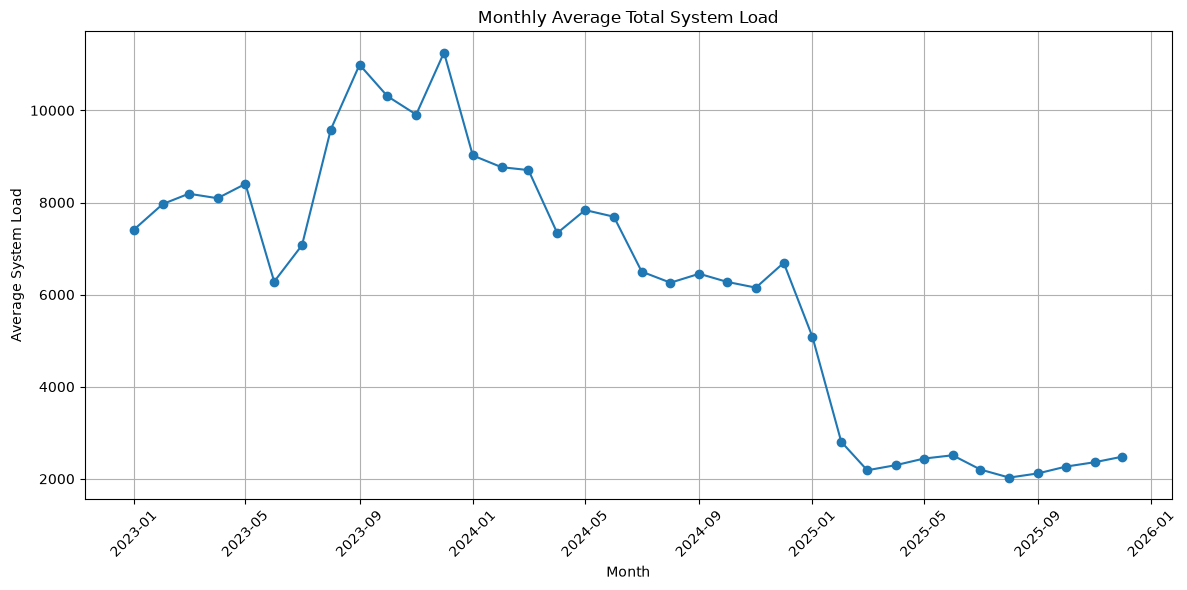

In [15]:
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_kpi["Date"],
    monthly_kpi["Total System Load"],
    marker="o"
)

plt.title("Monthly Average Total System Load")
plt.xlabel("Month")
plt.ylabel("Average System Load")
plt.xticks(rotation=45)
plt.grid(True)

plt.tight_layout()
plt.show()

In [16]:
highest_month = monthly_kpi.loc[
    monthly_kpi["Total System Load"].idxmax()
]

lowest_month = monthly_kpi.loc[
    monthly_kpi["Total System Load"].idxmin()
]

print("Highest Monthly Average Load:")
print("Month:", highest_month["Date"])
print("Average Load:", round(highest_month["Total System Load"], 2))

print("\nLowest Monthly Average Load:")
print("Month:", lowest_month["Date"])
print("Average Load:", round(lowest_month["Total System Load"], 2))

Highest Monthly Average Load:
Month: 2023-12-01 00:00:00
Average Load: 11255.26

Lowest Monthly Average Load:
Month: 2025-08-01 00:00:00
Average Load: 2026.9


In [17]:
highest_hhs_month = monthly_kpi.loc[
    monthly_kpi["Children in HHS Care"].idxmax()
]

lowest_hhs_month = monthly_kpi.loc[
    monthly_kpi["Children in HHS Care"].idxmin()
]

print("Highest Monthly Average HHS Care:")
print("Month:", highest_hhs_month["Date"])
print("HHS Care:", round(highest_hhs_month["Children in HHS Care"], 2))

print("\nLowest Monthly Average HHS Care:")
print("Month:", lowest_hhs_month["Date"])
print("HHS Care:", round(lowest_hhs_month["Children in HHS Care"], 2))

Highest Monthly Average HHS Care:
Month: 2023-12-01 00:00:00
HHS Care: 11068.63

Lowest Monthly Average HHS Care:
Month: 2025-08-01 00:00:00
HHS Care: 2001.3


In [18]:
highest_discharge_month = monthly_kpi.loc[
    monthly_kpi["Children discharged from HHS Care"].idxmax()
]

lowest_discharge_month = monthly_kpi.loc[
    monthly_kpi["Children discharged from HHS Care"].idxmin()
]

print("Highest Monthly Average HHS Discharge:")
print("Month:", highest_discharge_month["Date"])
print(
    "Average Discharge:",
    round(highest_discharge_month["Children discharged from HHS Care"], 2)
)

print("\nLowest Monthly Average HHS Discharge:")
print("Month:", lowest_discharge_month["Date"])
print(
    "Average Discharge:",
    round(lowest_discharge_month["Children discharged from HHS Care"], 2)
)

Highest Monthly Average HHS Discharge:
Month: 2023-12-01 00:00:00
Average Discharge: 358.11

Lowest Monthly Average HHS Discharge:
Month: 2025-11-01 00:00:00
Average Discharge: 8.37


In [19]:
highest_intake_month = monthly_kpi.loc[
    monthly_kpi["Net Daily Intake"].idxmax()
]

lowest_intake_month = monthly_kpi.loc[
    monthly_kpi["Net Daily Intake"].idxmin()
]

print("Highest Monthly Average Net Intake:")
print("Month:", highest_intake_month["Date"])
print("Net Intake:", round(highest_intake_month["Net Daily Intake"], 2))

print("\nLowest Monthly Average Net Intake:")
print("Month:", lowest_intake_month["Date"])
print("Net Intake:", round(lowest_intake_month["Net Daily Intake"], 2))

Highest Monthly Average Net Intake:
Month: 2024-02-01 00:00:00
Net Intake: 52.95

Lowest Monthly Average Net Intake:
Month: 2023-10-01 00:00:00
Net Intake: -254.95


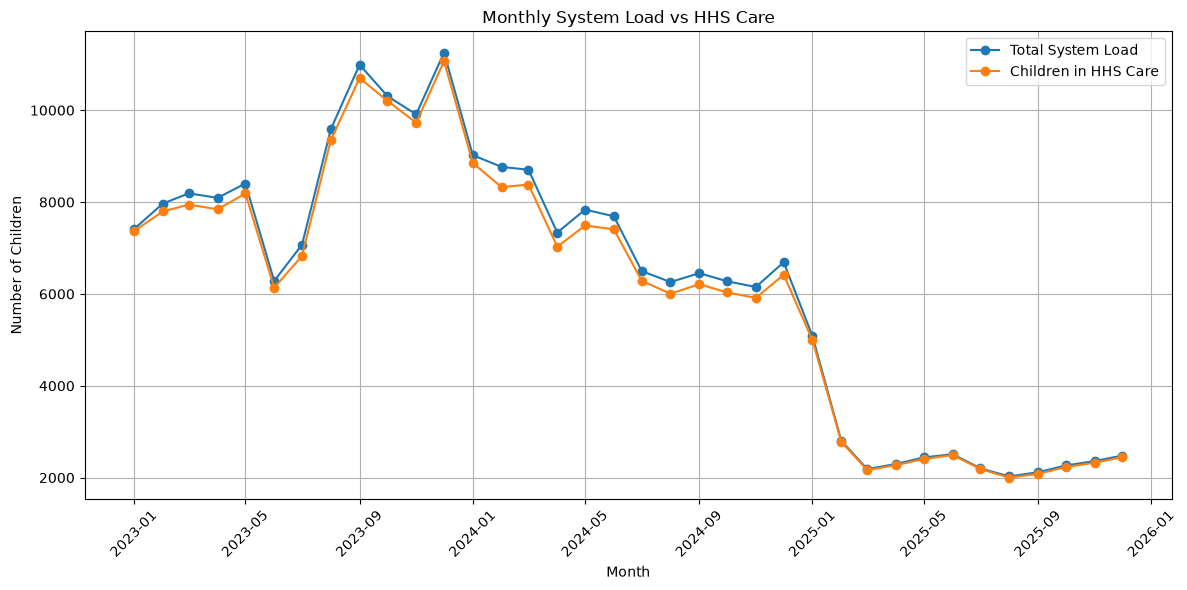

In [20]:
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_kpi["Date"],
    monthly_kpi["Total System Load"],
    marker="o",
    label="Total System Load"
)

plt.plot(
    monthly_kpi["Date"],
    monthly_kpi["Children in HHS Care"],
    marker="o",
    label="Children in HHS Care"
)

plt.title("Monthly System Load vs HHS Care")
plt.xlabel("Month")
plt.ylabel("Number of Children")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

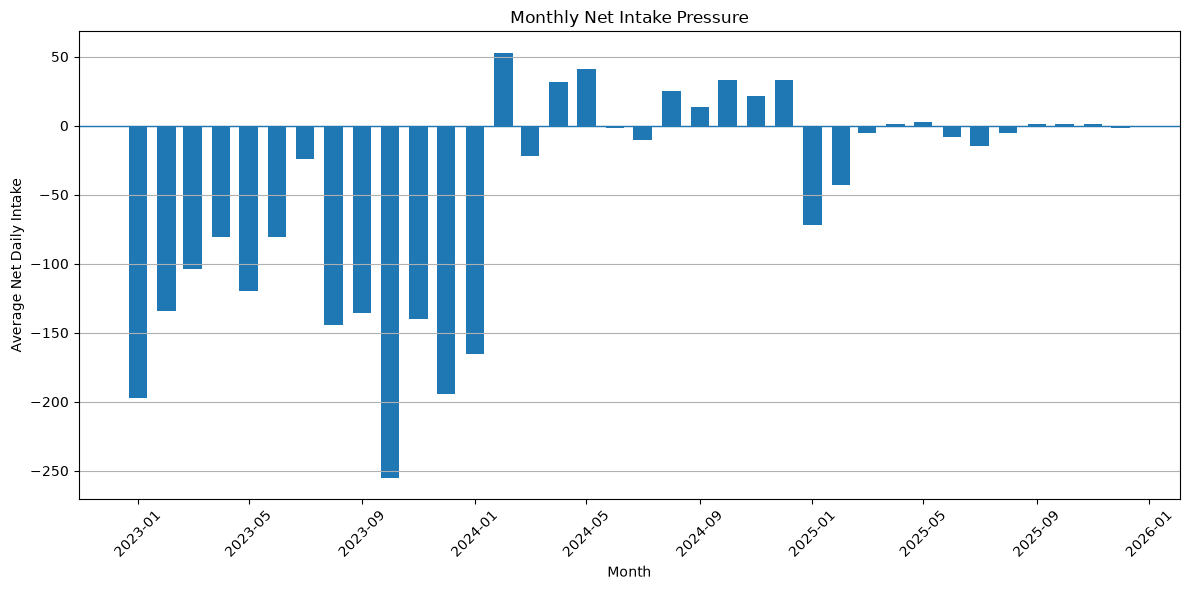

In [21]:
plt.figure(figsize=(12, 6))

plt.bar(
    monthly_kpi["Date"],
    monthly_kpi["Net Daily Intake"],
    width=20
)

plt.axhline(0, linewidth=1)

plt.title("Monthly Net Intake Pressure")
plt.xlabel("Month")
plt.ylabel("Average Net Daily Intake")
plt.xticks(rotation=45)
plt.grid(axis="y")

plt.tight_layout()
plt.show()